In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv('../Datasets/cleaned_algerian_fire_dataset.csv')

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29.0,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29.0,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26.0,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25.0,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27.0,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [5]:
df = df.drop(['day', 'month', 'year'], axis=1)
df.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes', 'Region'],
      dtype='str')

In [6]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [7]:
df['Classes'] = df['Classes'].str.strip()
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

In [8]:
df['Classes'] = df['Classes'].map({
    "not fire": 0,
    "fire": 1
})

In [9]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29.0,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29.0,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26.0,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25.0,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27.0,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  243 non-null    float64
 1   RH           243 non-null    int64  
 2   Ws           243 non-null    int64  
 3   Rain         243 non-null    float64
 4   FFMC         243 non-null    float64
 5   DMC          243 non-null    float64
 6   DC           243 non-null    float64
 7   ISI          243 non-null    float64
 8   BUI          243 non-null    float64
 9   FWI          243 non-null    float64
 10  Classes      243 non-null    int64  
 11  Region       243 non-null    int64  
dtypes: float64(8), int64(4)
memory usage: 22.9 KB


In [11]:
## independent and depenent features
X = df.drop('FWI', axis=1)
y = df['FWI']

In [12]:
from numpy import test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [13]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

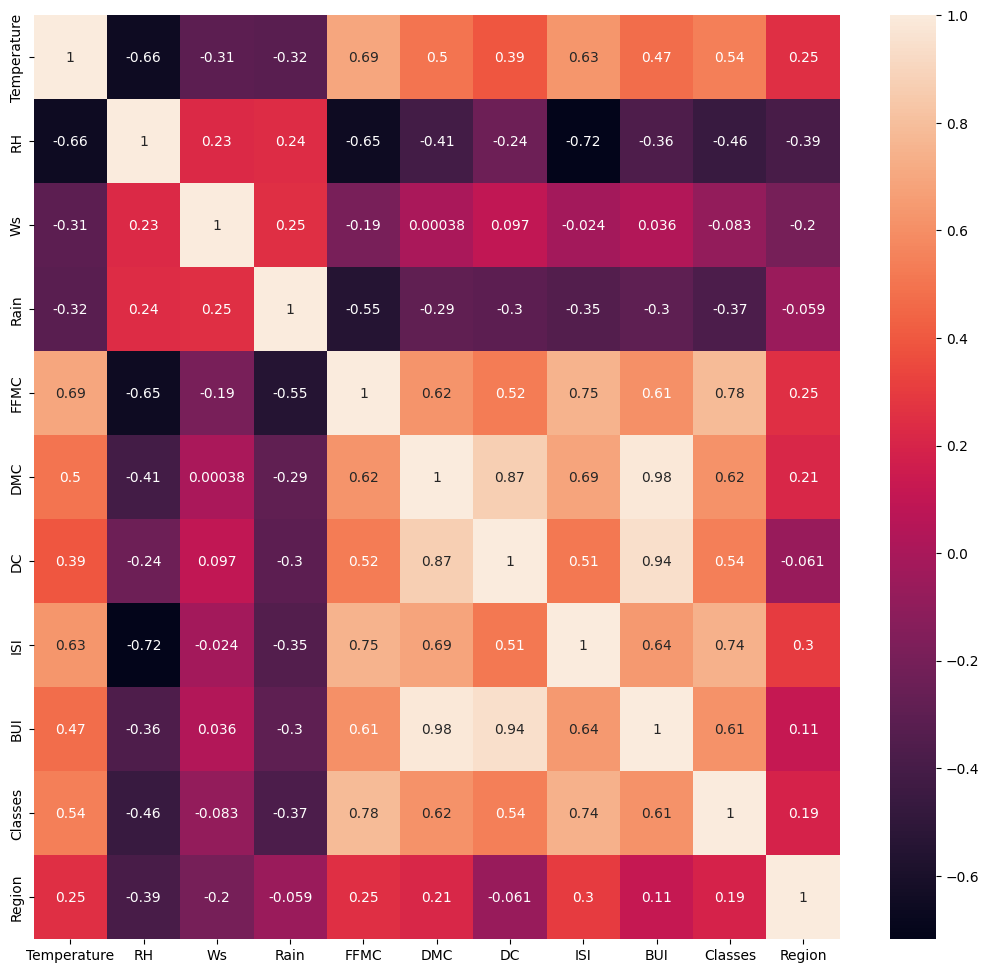

In [14]:
## check for collinearity
plt.figure(figsize=(13, 12))
corr = X_train.corr()
sns.heatmap(corr, annot=True)

In [15]:
def correlation(dataset, thresold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > thresold:
                col_name = corr_matrix.columns[i]
                col_corr.add(col_name)

    return col_corr

In [16]:
corr_features = correlation(X_train, 0.85)

In [17]:
## drop this column that is redundant 
X_train = X_train.drop(corr_features, axis=1)
X_test = X_test.drop(corr_features, axis=1)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [19]:
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

Text(0.5, 1.0, 'Data after Standardization')

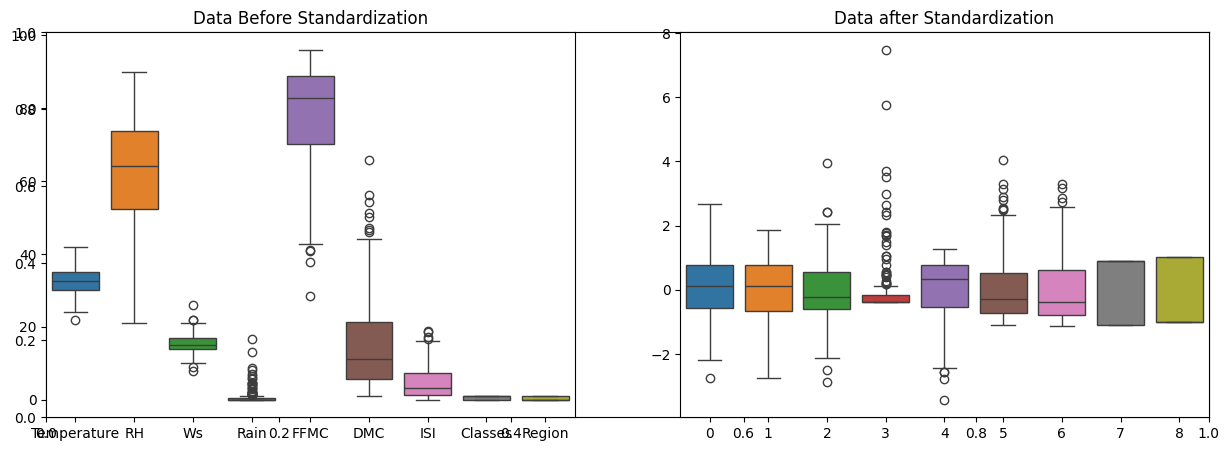

In [20]:
## Effects of standardization
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('Data Before Standardization')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_norm)
plt.title('Data after Standardization')

In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [24]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

0.9847657384266951
0.546823646524997
0.6742766873791582


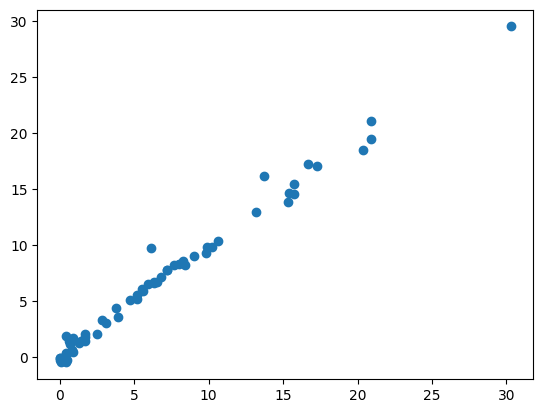

In [28]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_norm, y_train)
y_pred = lin_reg.predict(X_test_norm)
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))
plt.scatter(y_test, y_pred)

0.9264742326805692
1.1331759949144087
2.248345891897475


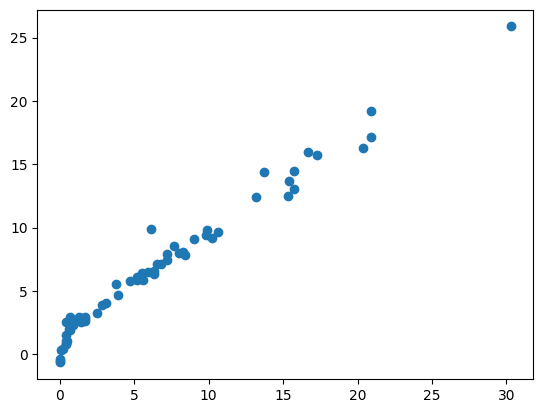

In [29]:
lasso_reg = Lasso()
lasso_reg.fit(X_train_norm, y_train)
y_pred = lasso_reg.predict(X_test_norm)
print(r2_score(y_pred, y_test))
print(mean_absolute_error(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))
plt.scatter(y_test, y_pred)

0.9834070933284212
0.5642305340105691
0.6949198918152073


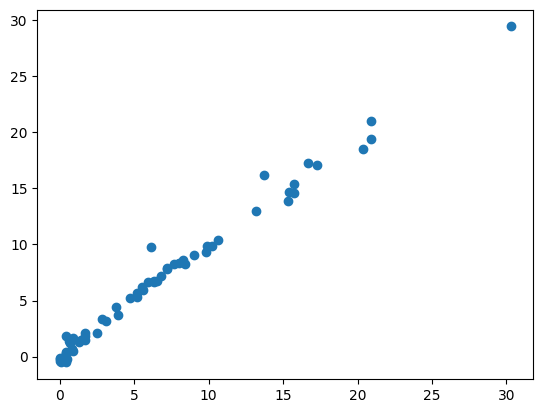

In [30]:
ridge_reg = Ridge()
ridge_reg.fit(X_train_norm, y_train)
y_pred = ridge_reg.predict(X_test_norm)
print(r2_score(y_pred, y_test))
print(mean_absolute_error(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))
plt.scatter(y_test, y_pred)

0.7814447243400927
1.8822353634895996
5.517251101025221


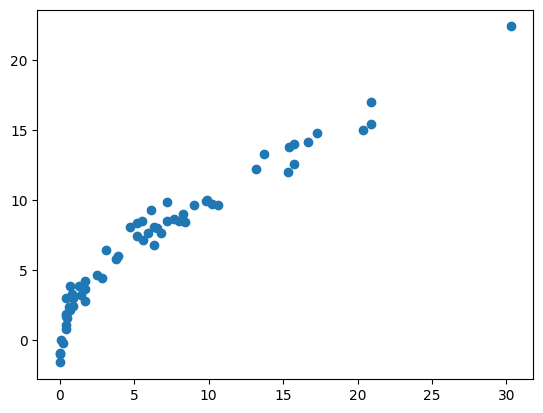

In [31]:
from sklearn.linear_model import ElasticNet
elas_reg = ElasticNet()
elas_reg.fit(X_train_norm, y_train)
y_pred = elas_reg.predict(X_test_norm)
print(r2_score(y_pred, y_test))
print(mean_absolute_error(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))
plt.scatter(y_test, y_pred)